<a href="https://colab.research.google.com/github/LombogRonnXherxes/CPE018-Emerging-Technologies-1/blob/main/Hands_on_Activity_4_1_Line_and_Circle_Detection_Lombog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 018
Code Title: | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision
1st Semester | AY 2023-2024
<hr> | <hr>
<u>**ACTIVITY NO.5 | Line and Circle Detection
**Name** | Lombog, Ronn Xherxes D.
**Section** | CPE31S2
**Date Performed**: | January 20, 2026
**Date Submitted**: | January 20, 2026
**Instructor**: | Engr. Maria Rizette Sayo

<hr>

## 1. Objectives

This activity aims to introduce students to openCV's APIs for Hough Transform.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Utilize openCV for circle and line detection.
* Analyze the use of hough Line and Circle function for finding objects in an image.

## 3. Procedures and Outputs

Detecting edges and contours are not only common and important tasks, they also constitute the basis for other complex operations. Lines and shape detection go hand in hand with edge and contour detection, so let's examine how OpenCV implements these.

### Line Detection

The theory behind lines and shape detection has its foundation in a technique called the Hough transform, invented by Richard Duda and Peter Hart, who extended (generalized) the work done by Paul Hough in the early 1960s.

Let's take a look at OpenCV's API for the Hough transforms.

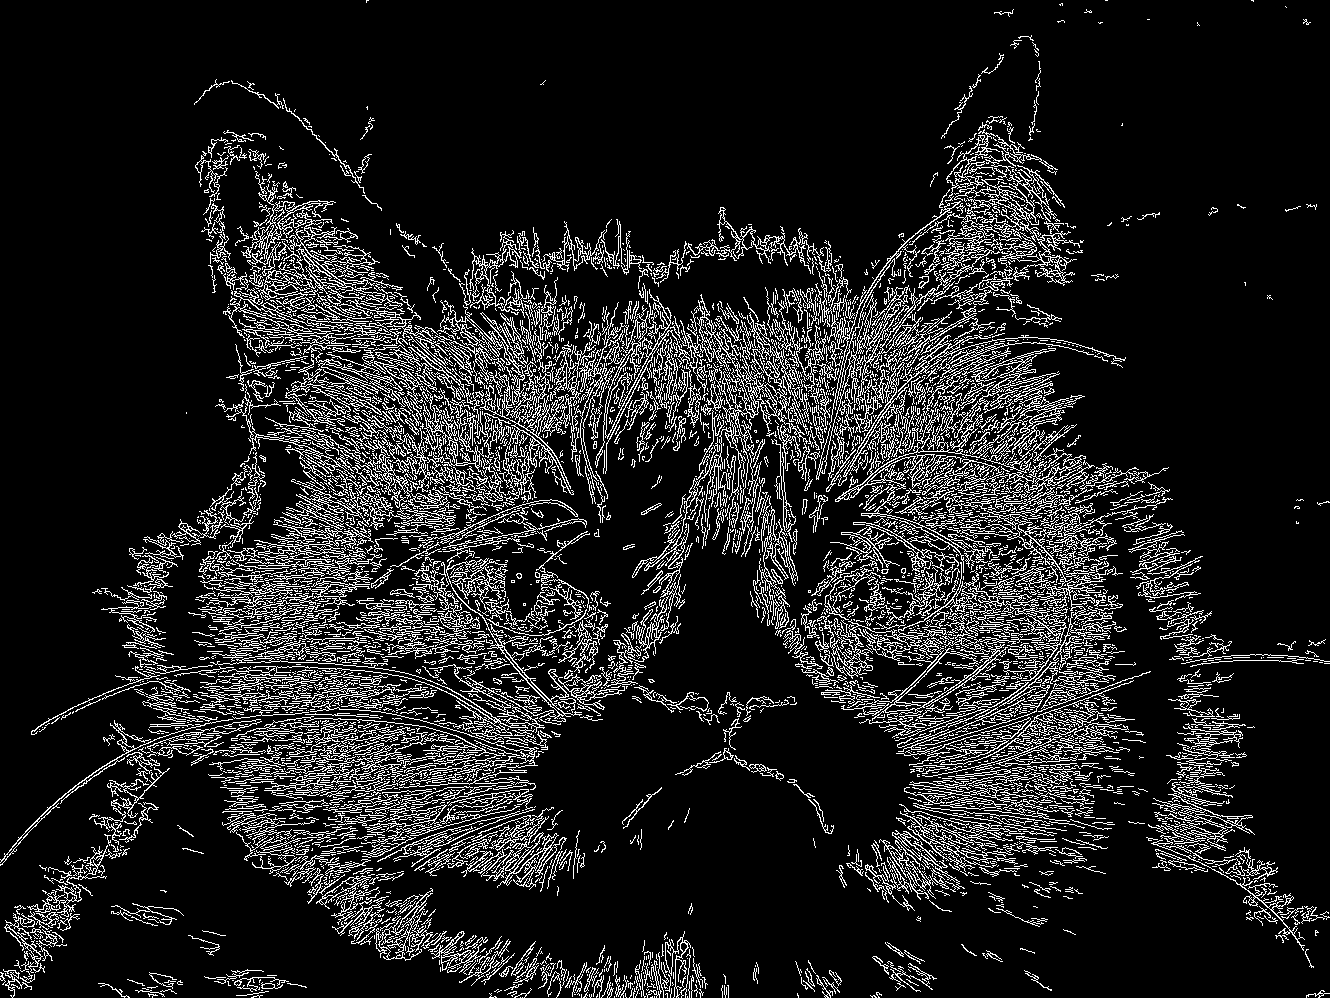

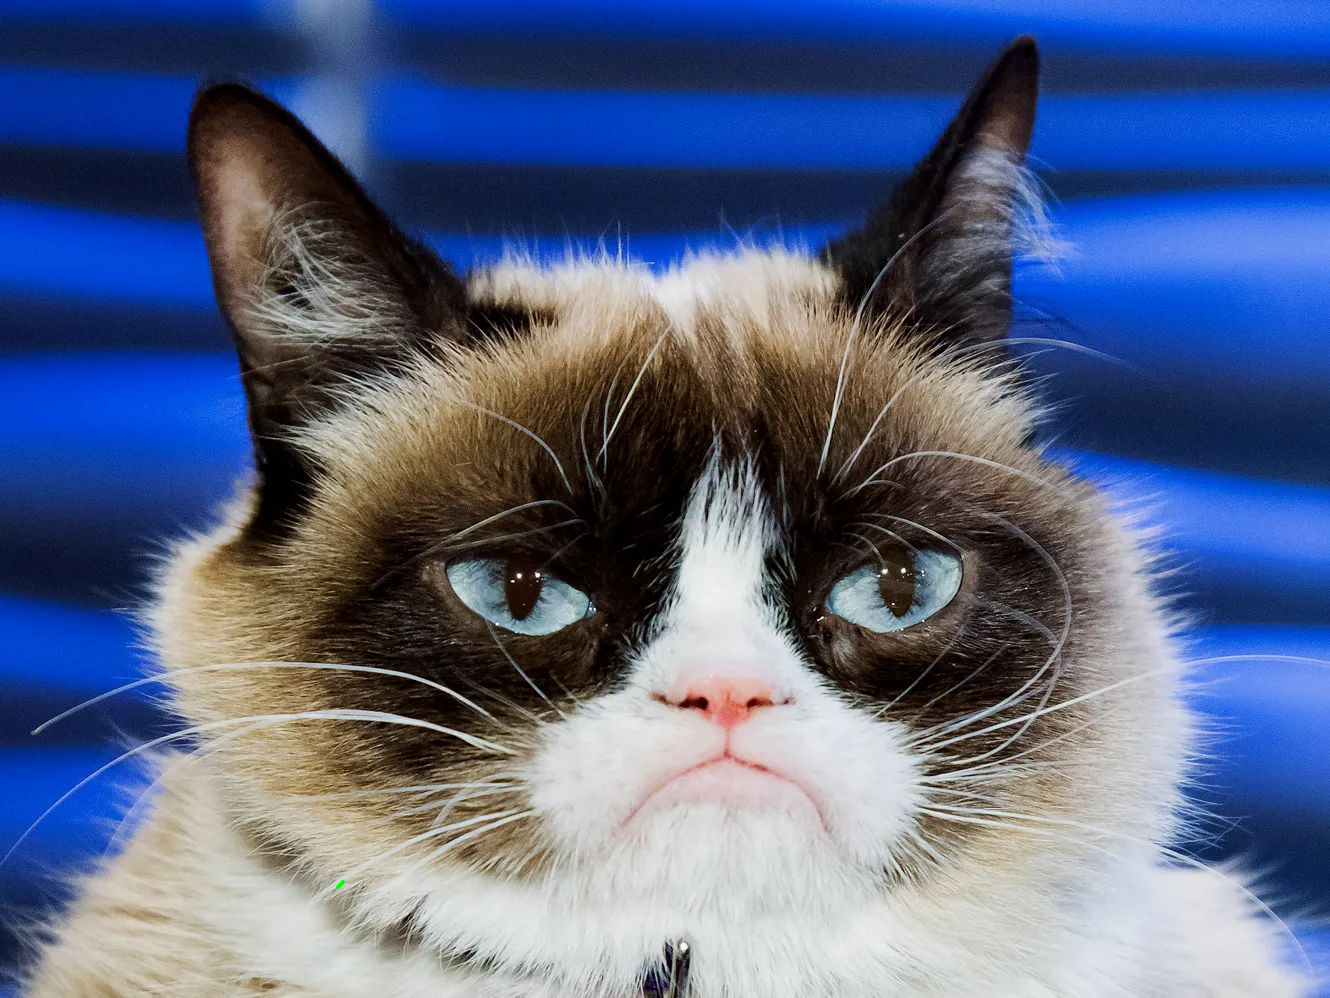

In [ ]:
# Image source: https://en.wikipedia.org/wiki/Keyboard_Cat

from google.colab.patches import cv2_imshow
import cv2
import numpy as np

img = cv2.imread('/content/drive/MyDrive/Colab Notebooks/Culture-Grumpy-Cat-487386121.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray,50,120)
minLineLength = 20
maxLineGap = 5
lines = cv2.HoughLinesP(edges,1,np.pi/180,100,minLineLength,
        maxLineGap)
for x1,y1,x2,y2 in lines[0]:
  cv2.line(img,(x1,y1),(x2,y2),(0,255,0),2)

cv2_imshow(edges)
cv2_imshow(img)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


The crucial point of this simple script —aside from the HoughLines function call— is the setting of minimum line length (shorter lines will be discarded) and the maximum line gap, which is the maximum size of a gap in a line before the two segments start being considered as separate lines.

Also note that the HoughLines function takes a single channel binary image, processed through the Canny edge detection filter. Canny is not a strict requirement, however; an image that's been denoised and only represents edges, is the ideal source for a Hough transform, so you will find this to be a common practice.

The parameters of HoughLinesP are as follows:
- The image we want to process.
- The geometrical representations of the lines, rho and theta, which are usually 1 and np.pi/180.
- The threshold, which represents the threshold below which a line is discarded. The Hough transform works with a system of bins and votes, with each bin representing a line, so any line with a minimum of the <threshold> votes is retained, the rest discarded.
- MinLineLength and MaxLineGap, which we mentioned previously

**Questions:**

1. Which line of code is responsible for setting the minimum line length?
2. What is the mathematical formula for Hough transform and explain how it finds lines.

### Circle Detection

OpenCV also has a function for detecting circles, called HoughCircles. It works in a very similar fashion to HoughLines, but where minLineLength and maxLineGap were the parameters to discard or retain lines, HoughCircles has a minimum distance between circles' centers, minimum, and maximum radius of the circles. Here's the obligatory example:

Before going into the sample code, check first: **What is the HoughCircles function and what are its parameters?**

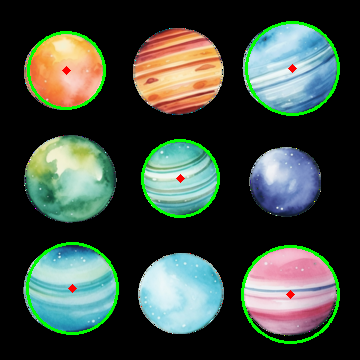

In [ ]:
import cv2
import numpy as np

# Our testing value
n = 15

planets = cv2.imread('/content/drive/MyDrive/Colab Notebooks/panets(2).png')
gray_img = cv2.cvtColor(planets, cv2.COLOR_BGR2GRAY)
img = cv2.medianBlur(gray_img, n) # We will change this value passed as parameter and observe results
cimg = cv2.cvtColor(img,cv2.COLOR_GRAY2BGR)
circles = cv2.HoughCircles(img,cv2.HOUGH_GRADIENT,1,120,
                            param1=100,param2=30,minRadius=0,
                                maxRadius=0)
circles = np.uint16(np.around(circles))

for i in circles[0,:]:
  # draw the outer circle
  cv2.circle(planets,(i[0],i[1]),i[2],(0,255,0),2)
  # draw the center of the circle
  cv2.circle(planets,(i[0],i[1]),2,(0,0,255),3)

cv2.imwrite("planets_circles.jpg", planets)
cv2_imshow(planets)

What happens to the code once you run **and the value of n is 5**?

The circle detection not circle most of the planets

Change the value to 9, **what happens to the image**?

When i change the value into 9 the circle encircle the 2 out 9 planets.

Lastly, change the value to 15, **what can you say about the resulting image?**

When i change it into 15, 5 out 9 planets is encircled

Provide an analysis of the output so far. How does the code help the changes in the resulting image?

The algorithm use median blurring to reduce noise before finding circles. Lower blur levels keep details crisp but may contain noise, whereas larger values minimize noise while removing key characteristics. The algorithm adjusts the blur setting to balance clarity and smoothness, which directly influences how correctly the circles are identified. Selecting the appropriate value increases detection and yields clearer results.

## 4. Supplementary Activity

The attached image contains coins used in the Philippines.

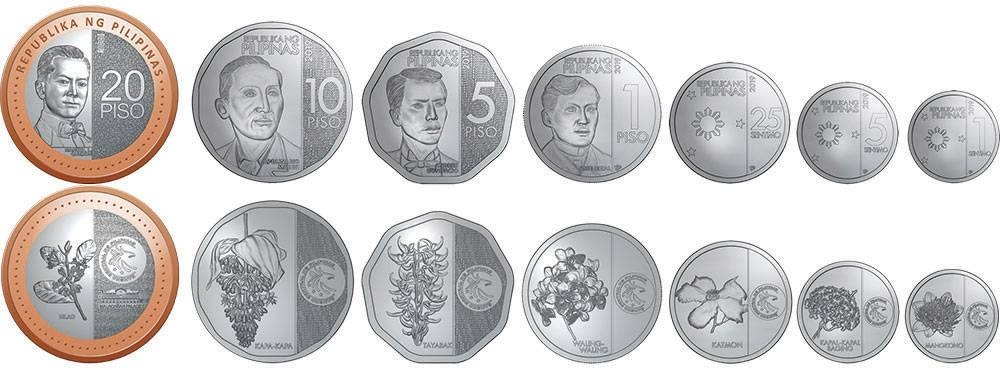

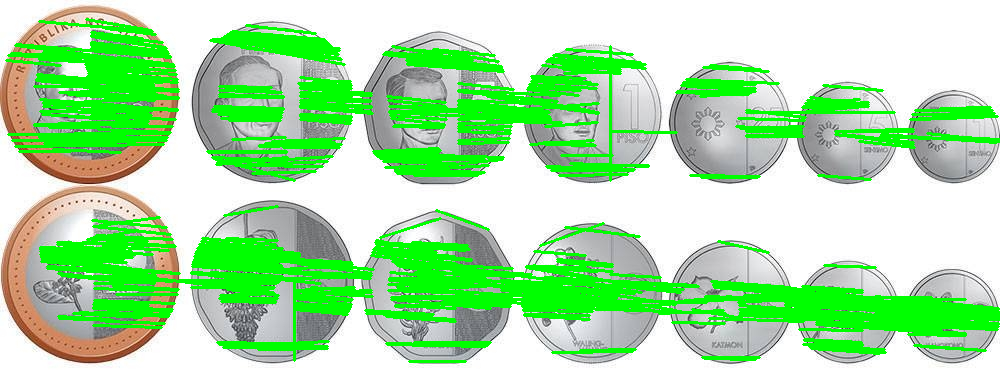

In [33]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load coin image
coins = cv2.imread('/content/drive/MyDrive/Colab Notebooks/barya.jpg')

gray = cv2.cvtColor(coins, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150)

lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi/180,
    threshold=100,
    minLineLength=50,
    maxLineGap=10
)

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(coins, (x1, y1), (x2, y2), (0, 255, 0), 2)

cv2_imshow(coins)

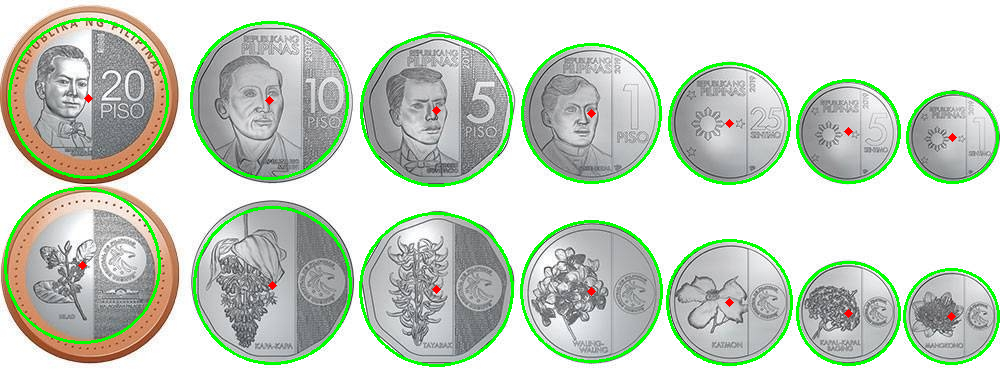

Total coins detected: 14


In [34]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

coins = cv2.imread('/content/drive/MyDrive/Colab Notebooks/barya.jpg')

gray = cv2.cvtColor(coins, cv2.COLOR_BGR2GRAY)
gray = cv2.medianBlur(gray, 5)

circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=90,
    param1=120,
    param2=45,
    minRadius=35,
    maxRadius=80
)

coin_count = 0

if circles is not None:
    circles = np.uint16(np.around(circles))
    coin_count = len(circles[0])

    for (x, y, r) in circles[0]:
        cv2.circle(coins, (x, y), r, (0, 255, 0), 2)
        cv2.circle(coins, (x, y), 2, (0, 0, 255), 3)

cv2_imshow(coins)
print("Total coins detected:", coin_count)

Your job is to count the amount of coins (denomation not included, no sum of prices; just the amount of coins present) through either line detection or circle detection.

- Create a function using line detection and pass this image as parameter, what is the output? Can you use houghlines to count circles?
- Create a function using circle detection and pass this image as parameter, show the output? Can you use houghcircles to count the circles?

Can you use houghlines to count circles?
- No. Coins are round objects, therefore line detection is not suited for counting them. HoughLines only recognizes straight edges, resulting in noisy data that cannot adequately depict circles.

Can you use houghcircles to count the circles?
- Yes. HoughCircles is intended to identify circular forms. It correctly recognizes each coin and allows us to count them by simply counting the identified circles.

## 5. Summary, Conclusions and Lessons Learned

This activity demonstrates how decreasing noise in a picture helps recognize circles more correctly. A modest bit of blurring eliminates extraneous details while leaving the outline of the coins visible. Excessive blurring makes the image indistinct and impairs detection. Using the proper settings produces cleaner photographs and more accurate results.

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*